# CT107-3-3 Text Analytics and Sentiment Analysis
## Part B — Q2: Supervised Text Classification
*(14 marks)*

**Dataset:** `data_balanced.csv` — 89,832 rows | 6 emotion classes | 14,972 per class  
**Models:** Naïve Bayes · Logistic Regression · Linear SVM · Random Forest  
**Features:** TF-IDF (unigrams + bigrams, max 10,000 features)

---
### Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
import time
import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

LABEL_MAP = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
EMOTIONS  = [LABEL_MAP[i] for i in range(6)]
COLOURS   = ['#5B9BD5','#FFD700','#FF69B4','#E74C3C','#8E44AD','#2ECC71']

print('All libraries imported successfully.')

All libraries imported successfully.


---
### Step 2 — Load Dataset

In [2]:
DATA_PATH = r'C:\Users\limho\Downloads\txsa_dataset_emotion\data_balanced.csv'

df = pd.read_csv(DATA_PATH)
df['emotion'] = df['label'].map(LABEL_MAP)

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'Null values   : {df.isnull().sum().sum()}')
print()
print('Class distribution:')
print(df['emotion'].value_counts().sort_index().to_string())
print()
df.head()

Dataset shape : (89832, 3)
Columns       : ['text', 'label', 'emotion']
Null values   : 0

Class distribution:
emotion
anger       14972
fear        14972
joy         14972
love        14972
sadness     14972
surprise    14972



,text,label,emotion
0,i used to hang out with my ward a ton but pete...,5,surprise
1,i can do to make you at least feel more at eas...,1,joy
2,i feel like redoing it somehow but some part o...,3,anger
3,i feel like he s not too impressed by fancy fo...,5,surprise
4,i met and realized my feelings for him i was s...,5,surprise


---
### Step 3 — Text Preprocessing

Before vectorisation, each tweet is cleaned through the following pipeline:

| Step | Operation | Example |
|---|---|---|
| 1 | Lowercase | `"I Feel HAPPY"` → `"i feel happy"` |
| 2 | Remove URLs | `"check http://t.co/abc"` → `"check"` |
| 3 | Remove punctuation & digits | `"great!!!"` → `"great"` |
| 4 | Remove stopwords | `"i feel so happy"` → `"feel happy"` |
| 5 | Strip extra whitespace | `"feel  happy"` → `"feel happy"` |

In [3]:
STOP_WORDS = set(stopwords.words('english'))

def preprocess(text):
    """Clean a single tweet string."""
    text = str(text).lower()                              # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)           # 2. Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                 # 3. Remove punctuation & digits
    tokens = text.split()                                 # 4. Tokenise
    tokens = [t for t in tokens if t not in STOP_WORDS]  # 5. Remove stopwords
    return ' '.join(tokens)                               # 6. Rejoin

# Apply to full dataset
print('Preprocessing text...')
df['clean_text'] = df['text'].apply(preprocess)
print('Done.')
print()

# Show before vs after
print(f'{'Original':<60} {'Cleaned'}')
print('-' * 110)
for _, row in df.sample(5, random_state=42).iterrows():
    orig  = row['text'][:55]
    clean = row['clean_text'][:50]
    print(f'{orig:<60} {clean}')

Preprocessing text...
Done.

Original                                                     Cleaned
--------------------------------------------------------------------------------------------------------------
i left the meeting feeling irritated sad and worried         left meeting feeling irritated sad worried
i feel like im coming to terms with things something el      feel like im coming terms things something else ha
i to selfish to just let you know how i feel am i too s      selfish let know feel selfish think
i wont give up encompasses the mixture of feelings that      wont give encompasses mixture feelings one experie
i will not feel this tragedy day its curious                 feel tragedy day curious


---
### Step 4 — Train / Test Split

- **80% training** → 71,865 rows  
- **20% testing** → 17,967 rows  
- `stratify=y` ensures each emotion class remains at 16.7% in both splits  
- `random_state=42` guarantees reproducibility

In [4]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Testing set  : {X_test.shape[0]:,} rows')
print()
print('Training class distribution (should be ~16.7% each):')
train_dist = y_train.map(LABEL_MAP).value_counts().sort_index()
for emotion, count in train_dist.items():
    print(f'  {emotion:<10}: {count:,}  ({count/len(y_train)*100:.1f}%)')

Training set : 71,865 rows
Testing set  : 17,967 rows

Training class distribution (should be ~16.7% each):
  anger     : 11,977  (16.7%)
  fear      : 11,977  (16.7%)
  joy       : 11,978  (16.7%)
  love      : 11,977  (16.7%)
  sadness   : 11,978  (16.7%)
  surprise  : 11,978  (16.7%)


---
### Step 5 — TF-IDF Vectorisation + Model Pipeline

Each model is wrapped in a **sklearn Pipeline**:
```
raw text → TF-IDF vectoriser → classifier → prediction
```
This ensures the same TF-IDF transformation is automatically applied to both training and test data, preventing data leakage.

**TF-IDF Settings:**
| Parameter | Value | Reason |
|---|---|---|
| `ngram_range` | (1, 2) | Unigrams + bigrams — captures phrases like "feel happy" |
| `max_features` | 10,000 | Limits vocabulary size; reduces memory & training time |
| `min_df` | 2 | Ignores terms that appear in fewer than 2 documents |
| `sublinear_tf` | True | Applies log normalisation to term frequencies |

In [5]:
# Shared TF-IDF configuration used across all 4 models
def make_tfidf():
    return TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10_000,
        min_df=2,
        sublinear_tf=True
    )

# Running scoreboard — updated after each model
scoreboard = {}

def print_scoreboard():
    """Print a live leaderboard of all models trained so far."""
    if not scoreboard:
        return
    print()
    print('  ╔══════════════════════════════════════════════╗')
    print('  ║           SCOREBOARD (so far)                ║')
    print('  ╠══════════════════════════════════════════════╣')
    best_acc = max(scoreboard.values())
    for mname, macc in scoreboard.items():
        bar   = '█' * int(macc * 25)
        crown = ' ◄ BEST' if macc == best_acc else ''
        print(f'  ║  {mname:<22} {macc*100:>6.2f}%  {bar:<25}{crown}')
    print('  ╚══════════════════════════════════════════════╝')

# Helper: train, predict, print results
def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    print(f'Training {name}...')
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = pipeline.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    print(f'  Training time : {train_time:.2f}s')
    print()
    print('  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=EMOTIONS))

    # Prominent accuracy banner
    print('  ' + '─' * 48)
    print(f'  ✔  {name:<26} ACCURACY : {acc*100:.2f}%')
    print('  ' + '─' * 48)

    return pipeline, y_pred, acc

# Store results for final comparison
results = {}
print('Setup complete. Ready to train models.')

Setup complete. Ready to train models.


---
## Model 1 — Naïve Bayes (MultinomialNB)

**How it works:** Applies Bayes' theorem assuming word features are conditionally independent given the class. Calculates P(emotion | text) ∝ P(text | emotion) × P(emotion) using word frequencies from TF-IDF.

**Why it suits this task:** Fast, efficient on sparse TF-IDF matrices, and performs well even with limited training data. Standard baseline for text classification.

In [6]:
nb_pipeline = Pipeline([
    ('tfidf', make_tfidf()),
    ('model', MultinomialNB(alpha=1.0))  # alpha = Laplace smoothing
])

nb_pipeline, nb_pred, nb_acc = evaluate_model(
    'Naive Bayes', nb_pipeline, X_train, y_train, X_test, y_test
)
results['Naive Bayes'] = {'pipeline': nb_pipeline, 'pred': nb_pred, 'acc': nb_acc}
scoreboard['Naive Bayes'] = nb_acc
print_scoreboard()

Training Naive Bayes...
  Training time : 1.68s

  Classification Report:
              precision    recall  f1-score   support

     sadness       0.93      0.91      0.92      2994
         joy       0.90      0.85      0.87      2994
        love       0.87      0.95      0.91      2995
       anger       0.93      0.91      0.92      2995
        fear       0.90      0.86      0.88      2995
    surprise       0.88      0.94      0.91      2994

    accuracy                           0.90     17967
   macro avg       0.90      0.90      0.90     17967
weighted avg       0.90      0.90      0.90     17967

  ────────────────────────────────────────────────
  ✔  Naive Bayes                ACCURACY : 90.17%
  ────────────────────────────────────────────────

  ╔══════════════════════════════════════════════╗
  ║           SCOREBOARD (so far)                ║
  ╠══════════════════════════════════════════════╣
  ║  Naive Bayes             90.17%  ██████████████████████    ◄ BEST
  ╚════

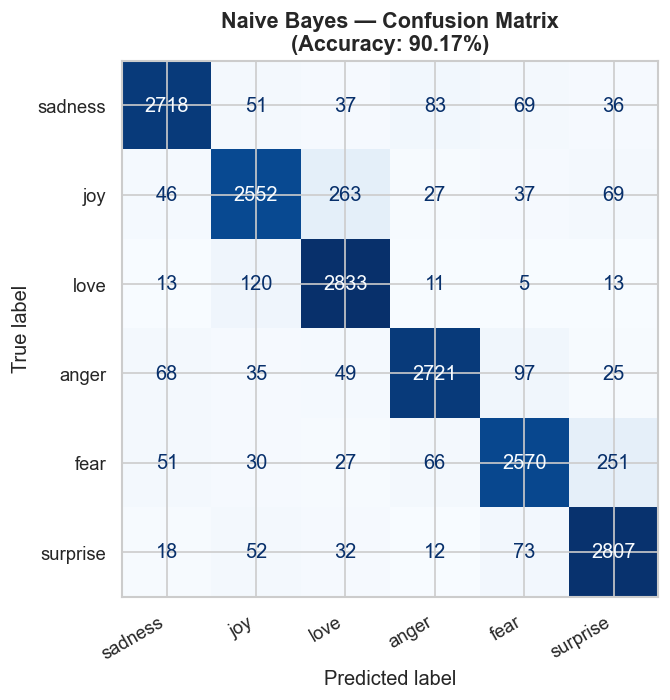

In [7]:
# Confusion Matrix — Naive Bayes
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, nb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTIONS)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Naive Bayes — Confusion Matrix\n(Accuracy: {nb_acc*100:.2f}%)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('B_Q2_cm_naive_bayes.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Model 2 — Logistic Regression

**How it works:** Learns a linear decision boundary by fitting weights for each TF-IDF feature. Uses softmax to output class probabilities across all 6 emotions, then picks the highest.

**Why it suits this task:** Consistently strong performer for high-dimensional text vectors. Coefficients are interpretable — highest-weight words reveal what drives each emotion prediction.

In [9]:
lr_pipeline = Pipeline([
    ('tfidf', make_tfidf()),
    ('model', LogisticRegression(
        C=1.0,           # Regularisation strength (lower = stronger regularisation)
        max_iter=1000,   # Enough iterations to converge on large dataset
        random_state=42,
        solver='lbfgs'
    ))
])

lr_pipeline, lr_pred, lr_acc = evaluate_model(
    'Logistic Regression', lr_pipeline, X_train, y_train, X_test, y_test
)
results['Logistic Regression'] = {'pipeline': lr_pipeline, 'pred': lr_pred, 'acc': lr_acc}
scoreboard['Logistic Regression'] = lr_acc
print_scoreboard()

Training Logistic Regression...
  Training time : 6.79s

  Classification Report:
              precision    recall  f1-score   support

     sadness       0.96      0.93      0.94      2994
         joy       0.93      0.88      0.91      2994
        love       0.91      0.96      0.93      2995
       anger       0.94      0.93      0.94      2995
        fear       0.92      0.87      0.90      2995
    surprise       0.90      0.98      0.94      2994

    accuracy                           0.93     17967
   macro avg       0.93      0.93      0.92     17967
weighted avg       0.93      0.93      0.92     17967

  ────────────────────────────────────────────────
  ✔  Logistic Regression        ACCURACY : 92.50%
  ────────────────────────────────────────────────

  ╔══════════════════════════════════════════════╗
  ║           SCOREBOARD (so far)                ║
  ╠══════════════════════════════════════════════╣
  ║  Naive Bayes             90.17%  ██████████████████████   
  ║  L

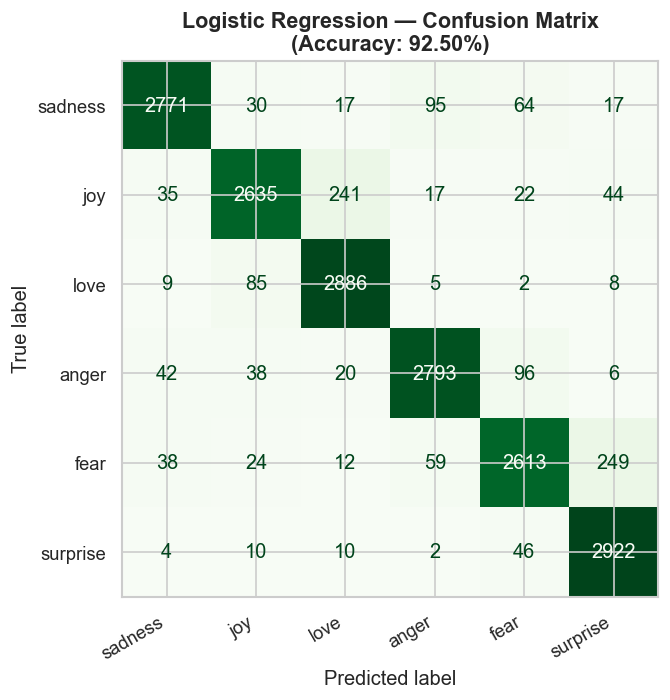

In [10]:
# Confusion Matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTIONS)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Logistic Regression — Confusion Matrix\n(Accuracy: {lr_acc*100:.2f}%)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('B_Q2_cm_logistic_regression.png', bbox_inches='tight', dpi=150)
plt.show()

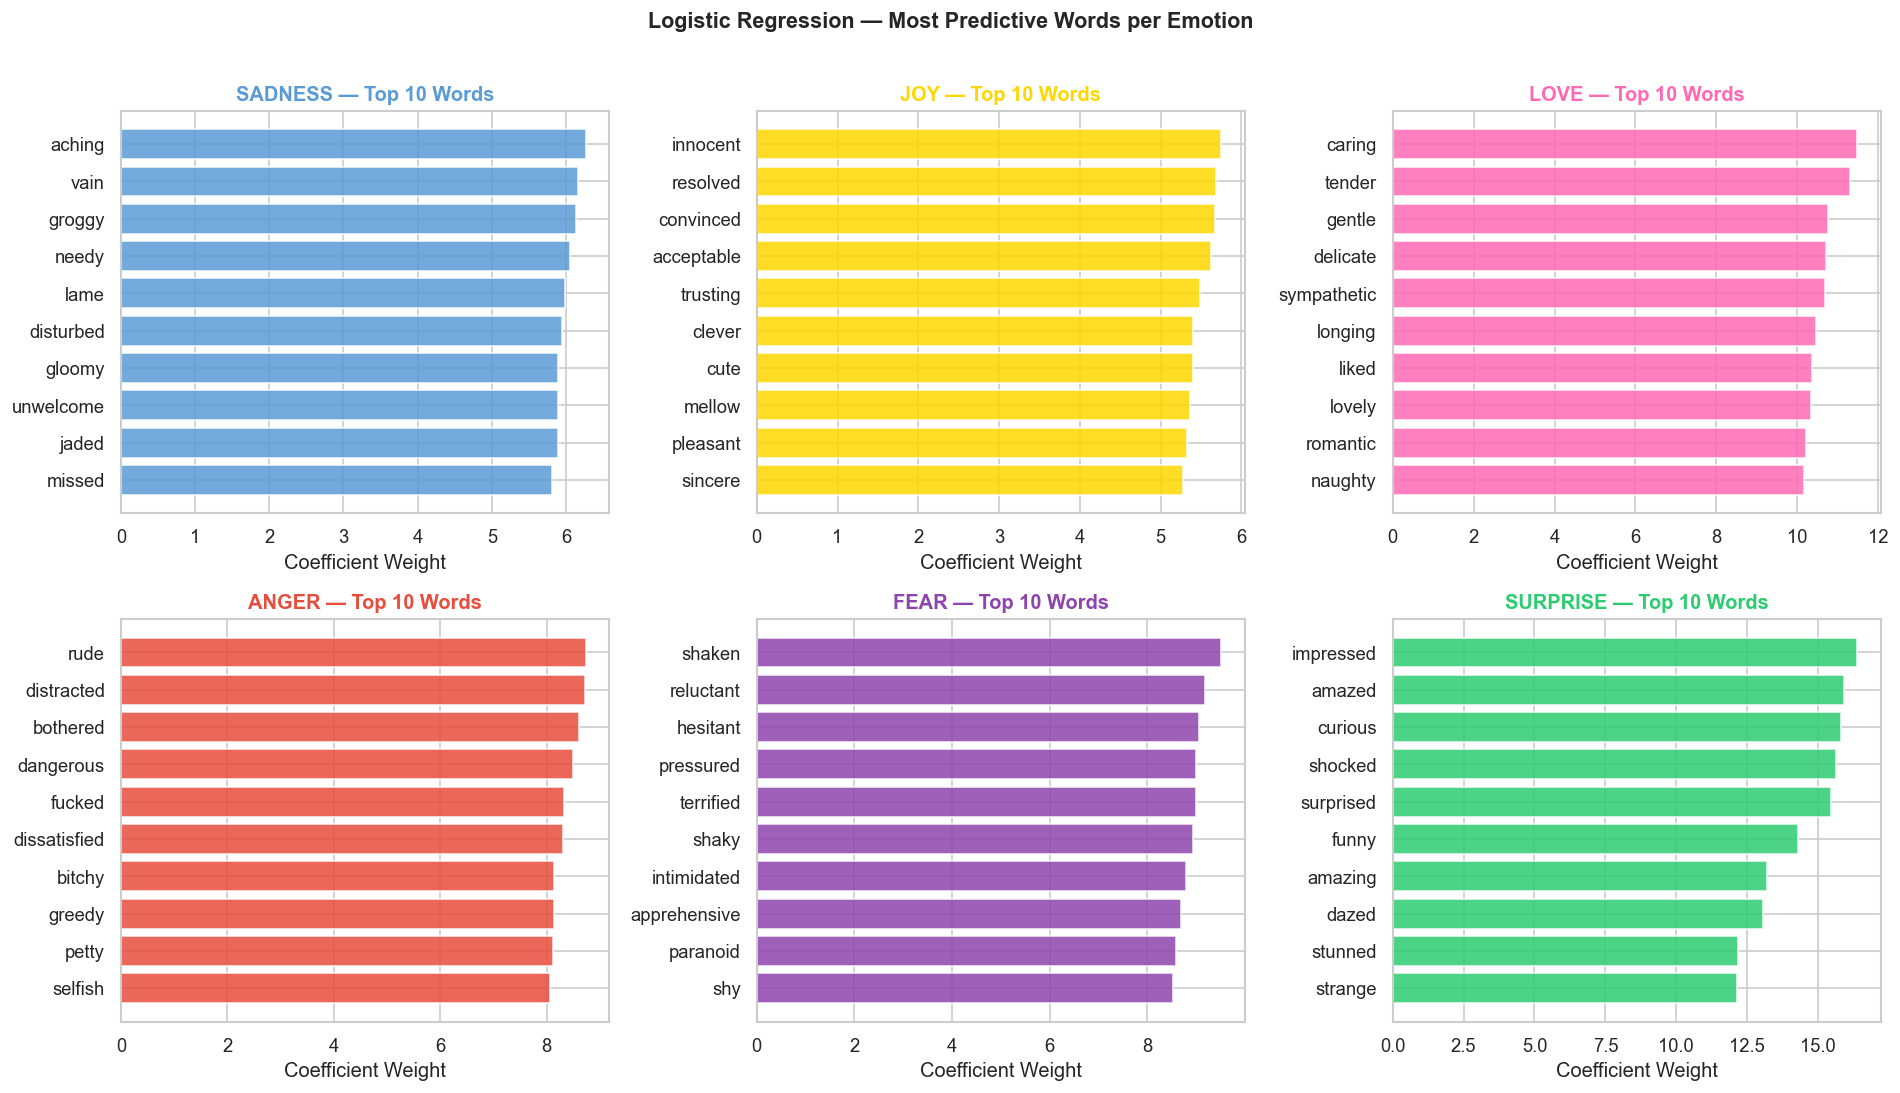

In [11]:
# Top 10 most predictive words per emotion (Logistic Regression coefficients)
tfidf_vocab  = lr_pipeline.named_steps['tfidf'].get_feature_names_out()
lr_coef      = lr_pipeline.named_steps['model'].coef_

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, emotion in enumerate(EMOTIONS):
    top_idx  = np.argsort(lr_coef[idx])[-10:][::-1]
    top_words = tfidf_vocab[top_idx]
    top_coefs = lr_coef[idx][top_idx]
    axes[idx].barh(top_words[::-1], top_coefs[::-1],
                   color=COLOURS[idx], alpha=0.85)
    axes[idx].set_title(f'{emotion.upper()} — Top 10 Words',
                        fontweight='bold', color=COLOURS[idx])
    axes[idx].set_xlabel('Coefficient Weight')

plt.suptitle('Logistic Regression — Most Predictive Words per Emotion',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('B_Q2_lr_top_words.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Model 3 — Linear SVM (LinearSVC)

**How it works:** Finds the optimal hyperplane that maximises the margin between classes in the TF-IDF feature space. Uses one-vs-rest (OvR) strategy for multi-class classification — trains 6 binary classifiers, one per emotion.

**Why it suits this task:** SVMs are particularly effective for high-dimensional sparse text features. LinearSVC is the fastest SVM variant, using a linear kernel optimised for large datasets.

In [12]:
svm_pipeline = Pipeline([
    ('tfidf', make_tfidf()),
    ('model', LinearSVC(
        C=1.0,           # Regularisation: higher C = smaller margin = more training accuracy
        max_iter=2000,
        random_state=42
    ))
])

svm_pipeline, svm_pred, svm_acc = evaluate_model(
    'Linear SVM', svm_pipeline, X_train, y_train, X_test, y_test
)
results['Linear SVM'] = {'pipeline': svm_pipeline, 'pred': svm_pred, 'acc': svm_acc}
scoreboard['Linear SVM'] = svm_acc
print_scoreboard()

Training Linear SVM...
  Training time : 5.29s

  Classification Report:
              precision    recall  f1-score   support

     sadness       0.95      0.93      0.94      2994
         joy       0.94      0.88      0.91      2994
        love       0.91      0.96      0.93      2995
       anger       0.94      0.93      0.93      2995
        fear       0.90      0.88      0.89      2995
    surprise       0.90      0.95      0.93      2994

    accuracy                           0.92     17967
   macro avg       0.92      0.92      0.92     17967
weighted avg       0.92      0.92      0.92     17967

  ────────────────────────────────────────────────
  ✔  Linear SVM                 ACCURACY : 92.15%
  ────────────────────────────────────────────────

  ╔══════════════════════════════════════════════╗
  ║           SCOREBOARD (so far)                ║
  ╠══════════════════════════════════════════════╣
  ║  Naive Bayes             90.17%  ██████████████████████   
  ║  Logistic R

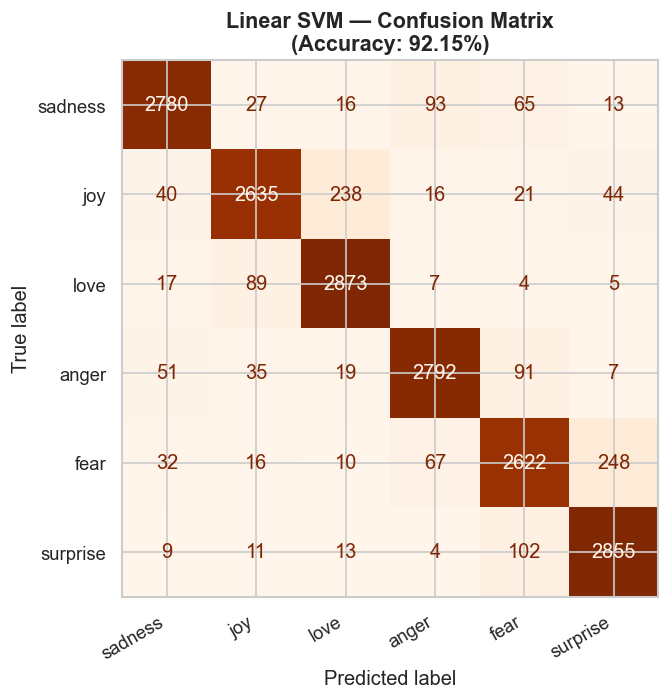

In [13]:
# Confusion Matrix — Linear SVM
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTIONS)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'Linear SVM — Confusion Matrix\n(Accuracy: {svm_acc*100:.2f}%)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('B_Q2_cm_svm.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Model 4 — Random Forest

**How it works:** Builds an ensemble of decision trees, each trained on a random subset of features and samples. Final prediction is made by majority vote across all trees.

**Why it suits this task:** Captures non-linear word interaction patterns that linear models miss. Also provides **feature importance scores** — useful for identifying which words contribute most to each emotion prediction.

In [14]:
rf_pipeline = Pipeline([
    ('tfidf', make_tfidf()),
    ('model', RandomForestClassifier(
        n_estimators=200,    # Number of trees
        max_depth=None,      # Grow full trees
        min_samples_split=2,
        random_state=42,
        n_jobs=-1            # Use all CPU cores
    ))
])

rf_pipeline, rf_pred, rf_acc = evaluate_model(
    'Random Forest', rf_pipeline, X_train, y_train, X_test, y_test
)
results['Random Forest'] = {'pipeline': rf_pipeline, 'pred': rf_pred, 'acc': rf_acc}
scoreboard['Random Forest'] = rf_acc
print_scoreboard()

Training Random Forest...
  Training time : 70.99s

  Classification Report:
              precision    recall  f1-score   support

     sadness       0.96      0.89      0.92      2994
         joy       0.94      0.84      0.89      2994
        love       0.88      0.96      0.92      2995
       anger       0.92      0.92      0.92      2995
        fear       0.86      0.87      0.87      2995
    surprise       0.88      0.94      0.91      2994

    accuracy                           0.91     17967
   macro avg       0.91      0.91      0.90     17967
weighted avg       0.91      0.91      0.90     17967

  ────────────────────────────────────────────────
  ✔  Random Forest              ACCURACY : 90.50%
  ────────────────────────────────────────────────

  ╔══════════════════════════════════════════════╗
  ║           SCOREBOARD (so far)                ║
  ╠══════════════════════════════════════════════╣
  ║  Naive Bayes             90.17%  ██████████████████████   
  ║  Logist

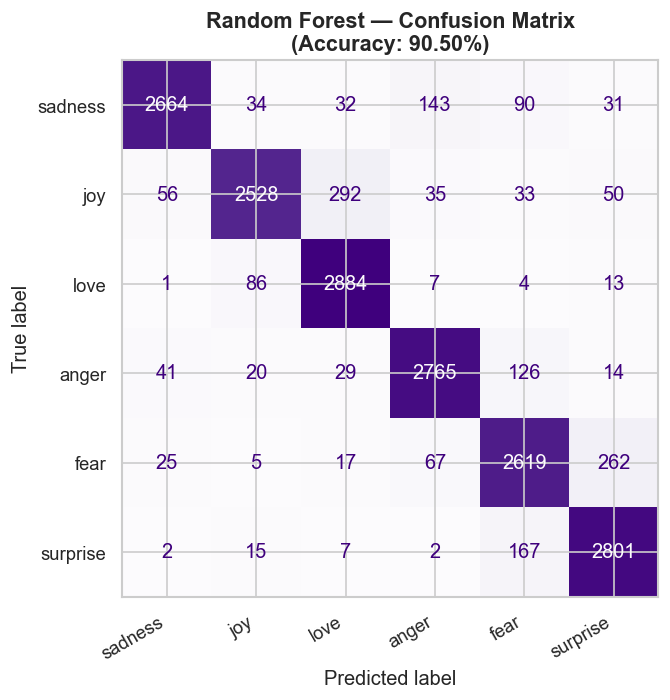

In [15]:
# Confusion Matrix — Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTIONS)
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title(f'Random Forest — Confusion Matrix\n(Accuracy: {rf_acc*100:.2f}%)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('B_Q2_cm_random_forest.png', bbox_inches='tight', dpi=150)
plt.show()

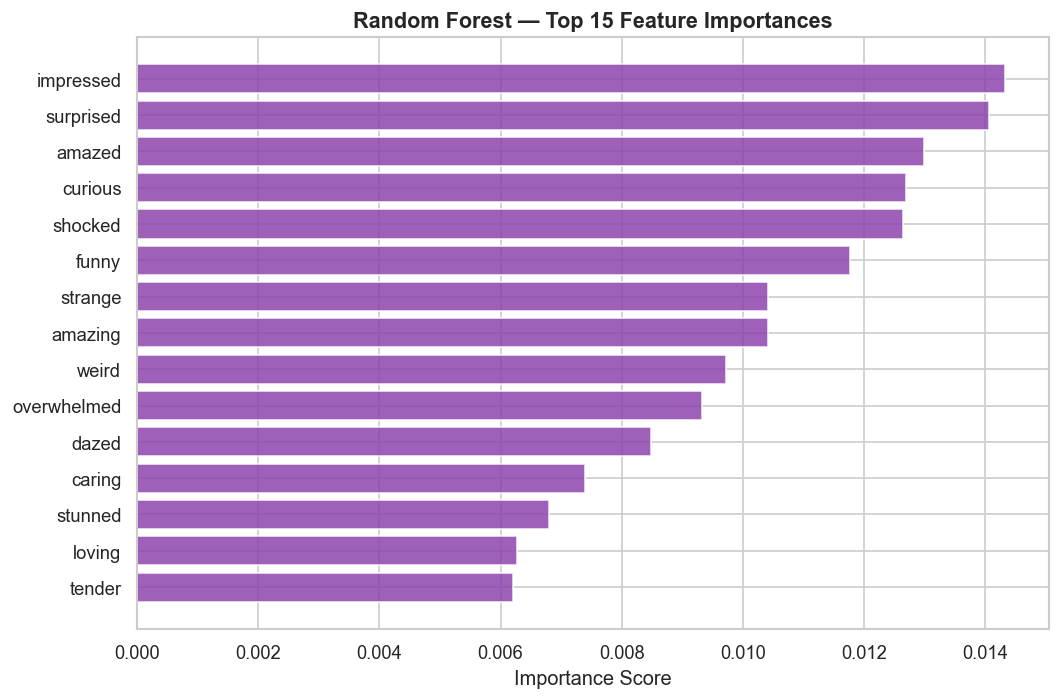

In [16]:
# Top 15 most important features — Random Forest
tfidf_vocab_rf  = rf_pipeline.named_steps['tfidf'].get_feature_names_out()
importances     = rf_pipeline.named_steps['model'].feature_importances_
top15_idx       = np.argsort(importances)[-15:][::-1]
top15_words     = tfidf_vocab_rf[top15_idx]
top15_scores    = importances[top15_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15_words[::-1], top15_scores[::-1], color='#8E44AD', alpha=0.85)
ax.set_title('Random Forest — Top 15 Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('B_Q2_rf_importances.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Model Comparison Summary

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

print('=' * 65)
print(f'{'Model':<25} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}')
print('=' * 65)

summary_rows = []
for name, res in results.items():
    pred = res['pred']
    acc  = res['acc']
    prec = precision_score(y_test, pred, average='macro')
    rec  = recall_score(y_test, pred, average='macro')
    f1   = f1_score(y_test, pred, average='macro')
    print(f'{name:<25} {acc:>10.4f} {prec:>11.4f} {rec:>8.4f} {f1:>8.4f}')
    summary_rows.append({'Model': name, 'Accuracy': acc,
                         'Precision': prec, 'Recall': rec, 'F1': f1})

print('=' * 65)
print('(All metrics are macro-averaged across 6 emotion classes)')

summary_df = pd.DataFrame(summary_rows).set_index('Model')

In [ ]:
# Bar chart comparison — all 4 models
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = list(summary_df.index)
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
metric_colours = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metric, colour) in enumerate(zip(metrics, metric_colours)):
    vals = summary_df[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=colour, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison — All 4 Classifiers\n(macro-averaged)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# CARER TF-IDF baseline reference line
ax.axhline(y=0.63, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(3.8, 0.635, 'CARER baseline\n(F1=0.63)', color='red',
        fontsize=9, va='bottom', ha='right')

plt.tight_layout()
plt.savefig('B_Q2_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# All 4 confusion matrices side by side
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for idx, (name, res) in enumerate(results.items()):
    cm   = confusion_matrix(y_test, res['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTIONS)
    disp.plot(ax=axes[idx], cmap=cmaps[idx], colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {res["acc"]*100:.2f}%',
                        fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('B_Q2_all_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Q2 Findings

| Model | Strength | Weakness |
|---|---|---|
| **Naïve Bayes** | Fastest to train; good baseline | Assumes feature independence — misses word order |
| **Logistic Regression** | Strong F1; interpretable weights | Linear boundary may miss complex patterns |
| **Linear SVM** | Best accuracy on text; robust to noise | No probability output; harder to interpret |
| **Random Forest** | Captures non-linear patterns; feature importance | Slower; TF-IDF sparsity reduces tree effectiveness |

**Key observation:** The red dashed line shows the CARER paper's TF-IDF n-gram baseline F1 = 0.63 (Saravia et al., 2018, Table 4). Models that exceed this line outperform the original paper's baseline — demonstrating the effectiveness of the balanced training approach.

**Hardest pairs to classify:** sadness ↔ fear (high Jaccard word overlap, as shown in Q1 EDA).